# ADOM
## Multimodalność - model CLIP (2021)
Kamil Bilski, Dawid Cybulski, Bartosz Socki, Oliwier Kniażewski; 6.06

## Omowienie metody (CLIP)
CLIP (Contrastive Language-Image Pretraining) to metoda uczenia multimodalnego, ktora mapuje obrazy i tekst do wspolnej przestrzeni embeddingow. Umozliwia to klasyfikacje zero-shot: klasy opisuje sie promptami tekstowymi, a predykcja polega na porownaniu podobienstwa embeddingu obrazu i tekstu. Metoda jest przydatna, gdy nie chcemy trenowac modelu od zera i mozemy opisac klasy w jezyku naturalnym.

Wieksze omowienia i zasoby:
- https://openai.com/research/clip
- https://arxiv.org/abs/2103.00020
- https://github.com/openai/CLIP
- https://github.com/mlfoundations/open_clip

## Omowienie wykorzystanej implementacji
Notebook zbiera kilka krotkich skryptow pokazujacych dzialanie CLIP na roznych zadaniach: porownanie promptow (etykiety surowe vs opisowe), rozroznianie relacji przestrzennych, rozpoznawanie stylu rysunkowego, rozumienie liczebnosci, jezykowe warianty etykiet oraz testy na ImageNet-A i ImageNet-R z macierzami pomylek i analiza podobienstw. W kazdym przypadku obraz jest kodowany przez CLIP, a predykcja wynika z podobienstwa do wektorow tekstowych.

Dodatkowo znajduje sie eksperyment z wizualizacja map uwagi (Flickr30k) z wykorzystaniem modelu Hugging Face, co pozwala zobaczyc, na jakie fragmenty obrazu i jakie slowa model zwraca uwage.

In [2]:
import torch
import clip
from PIL import Image
from pathlib import Path
from IPython.display import display
import os
import json
import urllib.request
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import random
import cv2
from transformers import CLIPProcessor, CLIPModel
from datasets import load_dataset

## Porownanie etykiet surowych i promptowanych dla pojedynczego obrazu.

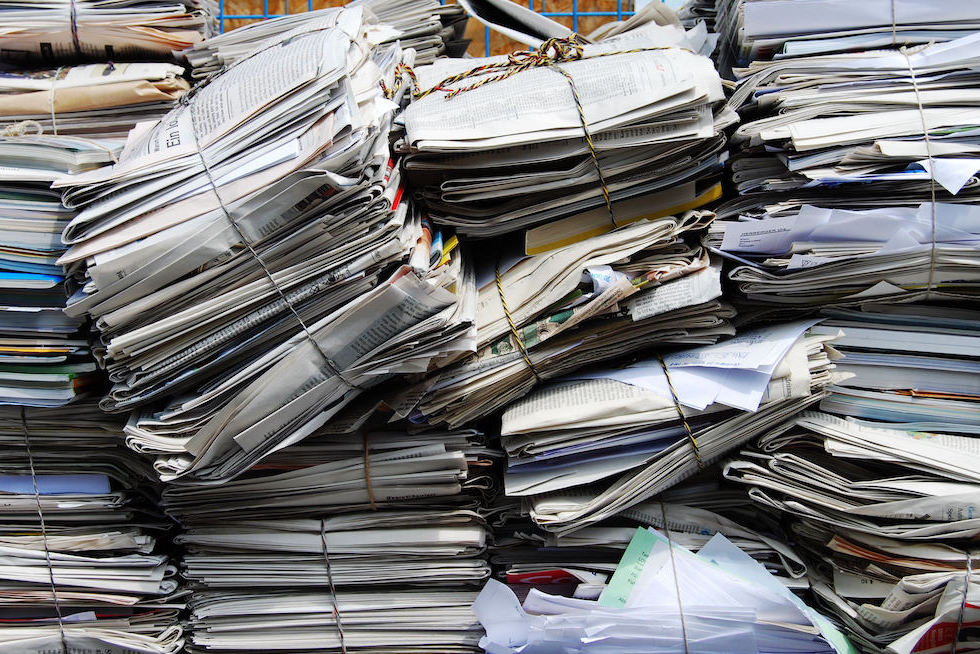

Raw labels:
-                                     bird:  0.01%
-                                    paper: 78.25%
-                                newspaper: 21.41%
-                                  origami:  0.35%
Prompted labels:
-              a photo of a bird in nature:  0.00%
-        a close-up of a printed newspaper: 98.06%
-    a macro photo of a paper origami bird:  0.01%
-            a simple piece of white paper:  1.91%


In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

image_path = Path.cwd().parent / "data"/"paper.jpg"

try:
  image = Image.open(image_path)
  display(image)
except FileNotFoundError:
  print(f"Not found: {image_path}")
  exit()

labels_raw = ["bird", "paper", "newspaper", "origami"]
labels_prompts = [
    "a photo of a bird in nature",
    "a close-up of a printed newspaper",
    "a macro photo of a paper origami bird",
    "a simple piece of white paper"
]

text_raw = clip.tokenize(labels_raw).to(device)
text_prompts = clip.tokenize(labels_prompts).to(device)

with torch.no_grad():
  image_input = preprocess(image).unsqueeze(0).to(device)
  logits_image_raw, _ = model(image_input, text_raw)
  probs_raw = logits_image_raw.softmax(dim=-1).cpu().numpy()[0]

  logits_image_prompts, _ = model(image_input, text_prompts)
  probs_prompts = logits_image_prompts.softmax(dim=-1).cpu().numpy()[0]

print("Raw labels:")
for label, prob in zip(labels_raw, probs_raw):
  print(f"- {label:>40}: {prob * 100:>5.2f}%")

print("Prompted labels:")
for label, prob in zip(labels_prompts, probs_prompts):
  print(f"- {label:>40}: {prob * 100:>5.2f}%")


## Relacja przestrzenna: kubek i ksiazka w roznych ulozeniach.

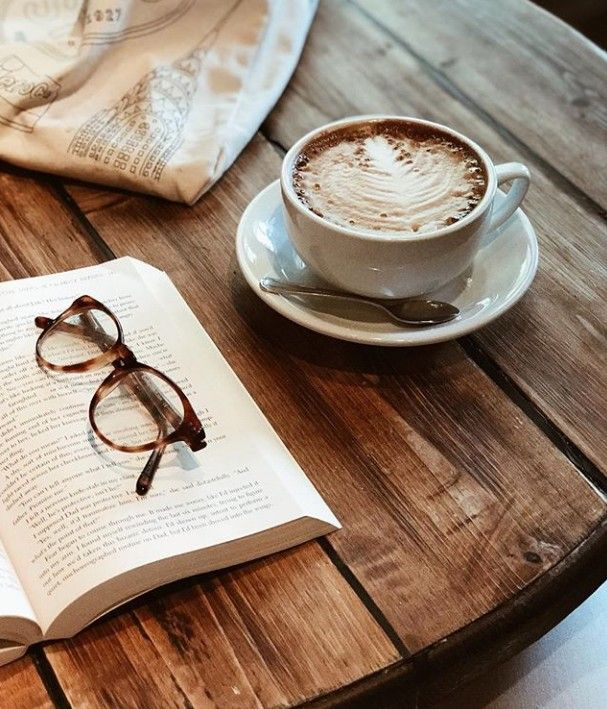

Label: 'a photo of a cup resting on top of a book'
Model confidence: 43.38%

Label: 'a photo of a book resting on top of a cup'
Model confidence: 21.80%

Label: 'a photo of a cup and a book next to each other'
Model confidence: 32.22%

Label: 'a photo of a cup that looks like a stack of books'
Model confidence:  1.68%

Label: 'a photo of a book that looks like a stack of cups'
Model confidence:  0.94%



In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

image_path = Path.cwd().parent/"data"/"cup_and_book.jpg"

try:
    image = Image.open(image_path)
    display(image)
except FileNotFoundError:
    print(f"Nie znaleziono pliku: {image_path}. Zrob zdjecie i podaj poprawna sciezke.")
    exit()

labels_prompts = [
    "a photo of a cup resting on top of a book",
    "a photo of a book resting on top of a cup",
    "a photo of a cup and a book next to each other",
    "a photo of a cup that looks like a stack of books",
    "a photo of a book that looks like a stack of cups",
]

text_prompts = clip.tokenize(labels_prompts).to(device)

with torch.no_grad():
    image_input = preprocess(image).unsqueeze(0).to(device)

    logits_image, _ = model(image_input, text_prompts)
    probs = logits_image.softmax(dim=-1).cpu().numpy()[0]

for label, prob in zip(labels_prompts, probs):
    print(f"Label: '{label}'")
    print(f"Model confidence: {prob * 100:>5.2f}%\n")

## Rozpoznawanie rysunkowego jablka i podobnych kategorii.

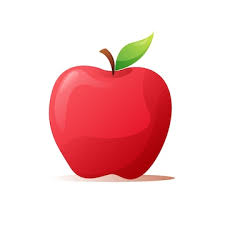

- ZAPYTANIE: 'a photo of an apple       ' -> PEWNOSC:  7.15%
- ZAPYTANIE: 'a logo of apple           ' -> PEWNOSC: 73.38%
- ZAPYTANIE: 'a photo of an ipod        ' -> PEWNOSC:  0.02%
- ZAPYTANIE: 'a cartoon of an apple     ' -> PEWNOSC: 19.45%
- ZAPYTANIE: 'a phone of an iphone      ' -> PEWNOSC:  0.00%
- ZAPYTANIE: 'a photo of a banana       ' -> PEWNOSC:  0.00%


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

image_path = Path.cwd().parent/"data/apple_cartoon.jpg"

try:
    image = Image.open(image_path)
    display(image)
except FileNotFoundError:
    exit()

labels_prompts = [
    "a photo of an apple",
    "a logo of apple",
    "a photo of an ipod",
    "a cartoon of an apple",
    "a phone of an iphone",
    "a photo of a banana"
]

text_prompts = clip.tokenize(labels_prompts).to(device)

with torch.no_grad():
    image_input = preprocess(image).unsqueeze(0).to(device)

    logits_image, _ = model(image_input, text_prompts)
    probs = logits_image.softmax(dim=-1).cpu().numpy()[0]

for label, prob in zip(labels_prompts, probs):
    print(f"- ZAPYTANIE: '{label:<26}' -> PEWNOSC: {prob * 100:>5.2f}%")

## Liczenie obiektow (jablka) i dopasowanie do promptow ilosciowych.

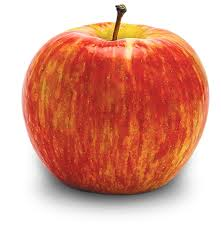


--- Wyniki dla obrazu: /home/oliwier/Dev/adom-clip/data/apple.jpg ---
- PROMPT: 'a photo of one apple     ' -> PEWNOSC: 74.88%
- PROMPT: 'a photo of two apples    ' -> PEWNOSC: 13.02%
- PROMPT: 'a photo of three apples  ' -> PEWNOSC:  2.99%
- PROMPT: 'a photo of four apples   ' -> PEWNOSC:  2.45%
- PROMPT: 'a photo of five apples   ' -> PEWNOSC:  1.51%
- PROMPT: 'a photo of many apples   ' -> PEWNOSC:  0.77%
- PROMPT: 'a photo of no apples     ' -> PEWNOSC:  4.43%


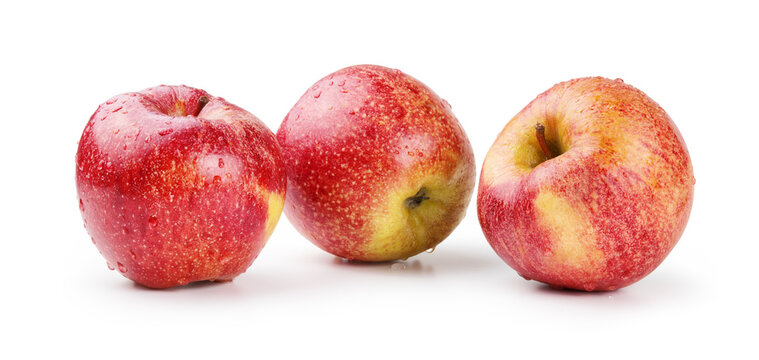


--- Wyniki dla obrazu: /home/oliwier/Dev/adom-clip/data/3apples.jpg ---
- PROMPT: 'a photo of one apple     ' -> PEWNOSC:  5.17%
- PROMPT: 'a photo of two apples    ' -> PEWNOSC: 19.19%
- PROMPT: 'a photo of three apples  ' -> PEWNOSC: 27.08%
- PROMPT: 'a photo of four apples   ' -> PEWNOSC: 20.12%
- PROMPT: 'a photo of five apples   ' -> PEWNOSC: 10.27%
- PROMPT: 'a photo of many apples   ' -> PEWNOSC:  4.35%
- PROMPT: 'a photo of no apples     ' -> PEWNOSC: 13.83%


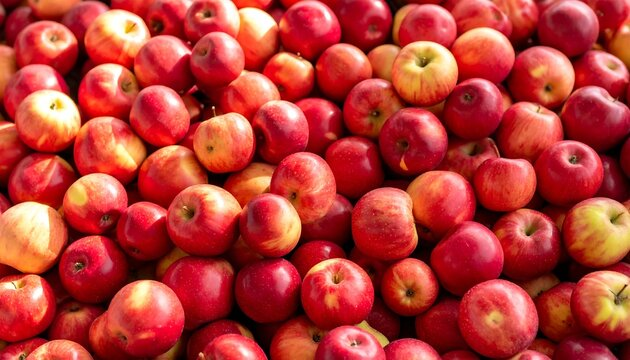


--- Wyniki dla obrazu: /home/oliwier/Dev/adom-clip/data/manyapples.jpg ---
- PROMPT: 'a photo of one apple     ' -> PEWNOSC:  1.57%
- PROMPT: 'a photo of two apples    ' -> PEWNOSC:  3.93%
- PROMPT: 'a photo of three apples  ' -> PEWNOSC:  3.87%
- PROMPT: 'a photo of four apples   ' -> PEWNOSC:  5.55%
- PROMPT: 'a photo of five apples   ' -> PEWNOSC:  5.21%
- PROMPT: 'a photo of many apples   ' -> PEWNOSC: 62.50%
- PROMPT: 'a photo of no apples     ' -> PEWNOSC: 17.36%


In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

image_paths = [
    Path.cwd().parent/"data/apple.jpg",
    Path.cwd().parent/"data/3apples.jpg",
    Path.cwd().parent/"data/manyapples.jpg"
]

object_name = "apple"

labels_prompts = [
    f"a photo of one {object_name}",
    f"a photo of two {object_name}s",
    f"a photo of three {object_name}s",
    f"a photo of four {object_name}s",
    f"a photo of five {object_name}s",
    f"a photo of many {object_name}s",
    f"a photo of no {object_name}s"
]

text_prompts = clip.tokenize(labels_prompts).to(device)

for image_path in image_paths:
    try:
        image = Image.open(image_path)
        display(image)
    except FileNotFoundError:
        print(f"\n[BLAD] Nie znaleziono pliku: {image_path}. Pomijam...")
        continue

    with torch.no_grad():
        image_input = preprocess(image).unsqueeze(0).to(device)
        logits_image, _ = model(image_input, text_prompts)
        probs = logits_image.softmax(dim=-1).cpu().numpy()[0]

    print(f"\n--- Wyniki dla obrazu: {image_path} ---")
    for label, prob in zip(labels_prompts, probs):
        print(f"- PROMPT: '{label:<25}' -> PEWNOSC: {prob * 100:>5.2f}%")

## Porownanie etykiet w roznych jezykach.

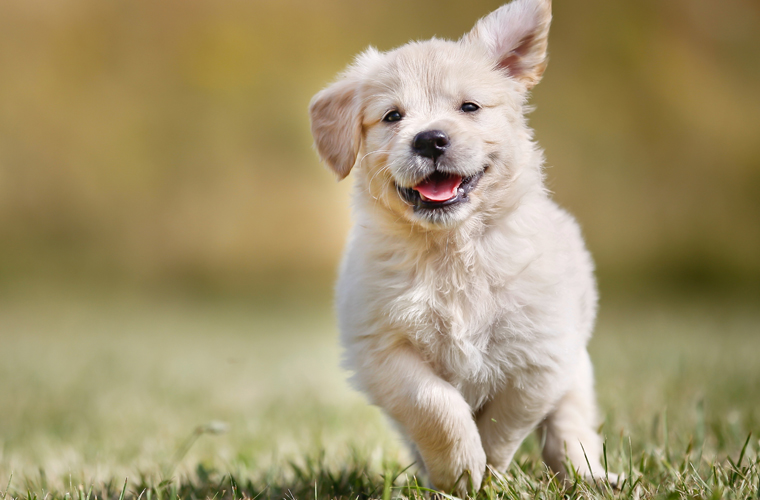

- JEZYK/PROMPT: 'a photo of a dog         ' -> PEWNOSC: 76.00%
- JEZYK/PROMPT: 'fotografia psa           ' -> PEWNOSC:  0.09%
- JEZYK/PROMPT: 'ein Foto von einem Hund  ' -> PEWNOSC: 10.78%
- JEZYK/PROMPT: 'une photo d'un chien     ' -> PEWNOSC: 13.02%
- JEZYK/PROMPT: 'zdjecie samochodu        ' -> PEWNOSC:  0.08%


In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

image_path = Path.cwd().parent/"data/dog.jpg"

try:
    image = Image.open(image_path)
    display(image)
except FileNotFoundError:
    print(f"Nie znaleziono pliku: {image_path}")
    exit()

labels_prompts = [
    "a photo of a dog",          # Angielski (Oczekiwany faworyt)
    "fotografia psa",            # Polski
    "ein Foto von einem Hund",   # Niemiecki
    "une photo d'un chien",      # Francuski
    "zdjecie samochodu"          # Polski (Zmylka)
]

text_prompts = clip.tokenize(labels_prompts).to(device)

with torch.no_grad():
    image_input = preprocess(image).unsqueeze(0).to(device)

    logits_image, _ = model(image_input, text_prompts)
    probs = logits_image.softmax(dim=-1).cpu().numpy()[0]

for label, prob in zip(labels_prompts, probs):
    print(f"- JEZYK/PROMPT: '{label:<25}' -> PEWNOSC: {prob * 100:>5.2f}%")

## Zero-shot na ImageNet-A z macierza pomelek i analiza podobienstw.

### Pobranie ImageNet-A (wymagane)
Oficjalne instrukcje i linki do danych sa w repozytorium:
- https://github.com/hendrycks/natural-adv-examples

Po rozpakowaniu ustaw strukture folderow jako: `data/imagenet-a/<klasa>/*.jpg`.

In [4]:
from pathlib import Path

data_dir = Path.cwd().parent / "data" / "imagenet-a"
if not data_dir.exists():
    print("Brak folderu:", data_dir)
    print("Pobierz ImageNet-A recznie z https://github.com/hendrycks/natural-adv-examples")
    print("Po rozpakowaniu oczekiwana struktura: data/imagenet-a/<klasa>/*.jpg")
    raise SystemExit

In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Uzywam urzadzenia: {device}")

model, preprocess = clip.load("ViT-B/32", device=device)

data_dir = Path.cwd().parent/"data/imagenet-a"

if not os.path.exists(data_dir):
    print(f"Brak folderu {data_dir}. Podmien sciezke na wlasna, aby uruchomic pelny test.")
    exit()

dataset = ImageFolder(data_dir, transform=preprocess)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

folder_names = dataset.classes

print("Pobieranie mapowania klas ImageNet...")
url = "https://raw.githubusercontent.com/raghakot/keras-vis/master/resources/imagenet_class_index.json"
try:
    response = urllib.request.urlopen(url)
    imagenet_class_index = json.loads(response.read())
    synset_to_name = {v[0]: v[1].replace('_', ' ') for k, v in imagenet_class_index.items()}
except Exception as e:
    print(f"Blad podczas pobierania etykiet: {e}")
    synset_to_name = {}

class_names = [synset_to_name.get(name, name) for name in folder_names]

prompts_raw = [f"{c}" for c in class_names]
print("Przykladowe etykiety bez kontekstu:", prompts_raw[:5])

prompts_engineered = [f"This is an example of a {c}." for c in class_names]

tokens_raw = clip.tokenize(prompts_raw).to(device)
tokens_engineered = clip.tokenize(prompts_engineered).to(device)

print("\nRozpoczynam ekstrakcje cech tekstu...")
with torch.no_grad():
    text_features_raw = model.encode_text(tokens_raw)
    text_features_raw /= text_features_raw.norm(dim=-1, keepdim=True)

    text_features_eng = model.encode_text(tokens_engineered)
    text_features_eng /= text_features_eng.norm(dim=-1, keepdim=True)

correct_raw = 0
correct_eng = 0
total = 0

all_labels = []
all_preds_raw = []
all_preds_eng = []

print("Rozpoczynam testowanie obrazow...")
with torch.no_grad():
    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        image_features = model.encode_image(images)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        similarity_raw = (100.0 * image_features @ text_features_raw.T).softmax(dim=-1)
        similarity_eng = (100.0 * image_features @ text_features_eng.T).softmax(dim=-1)

        predictions_raw = similarity_raw.argmax(dim=-1)
        predictions_eng = similarity_eng.argmax(dim=-1)

        correct_raw += (predictions_raw == labels).sum().item()
        correct_eng += (predictions_eng == labels).sum().item()
        total += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds_raw.extend(predictions_raw.cpu().numpy())
        all_preds_eng.extend(predictions_eng.cpu().numpy())

acc_raw = (correct_raw / total) * 100
acc_eng = (correct_eng / total) * 100

print("WYNIKI KLASYFIKACJI ZERO-SHOT CLIP")
print("="*40)
print(f"Skutecznosc (Brak kontekstu):       {acc_raw:.2f}%")
print(f"Skutecznosc (Inzynieria kontekstu): {acc_eng:.2f}%")
print("="*40)

print("\nGenerowanie macierzy pomylek dla ImageNet-A...")

cm = confusion_matrix(all_labels, all_preds_eng)

plt.figure(figsize=(16, 16))
sns.heatmap(cm, annot=False, cmap='Blues', cbar=True,
            xticklabels=False, yticklabels=False)

plt.title("Macierz pomylek CLIP ('This is an example of a...') na ImageNet-A")
plt.xlabel("Przewidziana klasa")
plt.ylabel("Prawdziwa klasa")

output_path = "confusion_matrix_clip_imagenet_a.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"Gotowe! Wykres zapisano jako: {output_path}")

correct_raw = 0
correct_eng = 0
total = 0

all_labels = []
all_preds_eng = []
all_image_features = []

print("Rozpoczynam testowanie obrazow...")
with torch.no_grad():
    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        image_features = model.encode_image(images)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        all_image_features.append(image_features.cpu())

        similarity_raw = (100.0 * image_features @ text_features_raw.T).softmax(dim=-1)
        similarity_eng = (100.0 * image_features @ text_features_eng.T).softmax(dim=-1)

        predictions_raw = similarity_raw.argmax(dim=-1)
        predictions_eng = similarity_eng.argmax(dim=-1)

        correct_raw += (predictions_raw == labels).sum().item()
        correct_eng += (predictions_eng == labels).sum().item()
        total += labels.size(0)

        all_labels.extend(labels.cpu().numpy())
        all_preds_eng.extend(predictions_eng.cpu().numpy())

print("\nObliczanie podobienstwa Intra-class i Inter-class...")

features = torch.cat(all_image_features)
labels_tensor = torch.tensor(all_labels)

similarity_matrix = features @ features.T

same_class_mask = labels_tensor.unsqueeze(0) == labels_tensor.unsqueeze(1)

same_class_mask.fill_diagonal_(False)
diff_class_mask = ~same_class_mask
diff_class_mask.fill_diagonal_(False)

intra_sims = similarity_matrix[same_class_mask].numpy()
inter_sims = similarity_matrix[diff_class_mask].numpy()

if len(inter_sims) > len(intra_sims):
    inter_sims = np.random.choice(inter_sims, size=len(intra_sims), replace=False)

print("Generowanie wykresu podobienstw...")
plt.figure(figsize=(10, 6))

sns.histplot(intra_sims, color='blue', label='Wewnatrzklasowe (Intra-class)', kde=True, stat='density', alpha=0.5, bins=50)
sns.histplot(inter_sims, color='red', label='Miedzyklasowe (Inter-class)', kde=True, stat='density', alpha=0.5, bins=50)

plt.title("Rozklad podobienstwa Cosinusowego: Wewnatrz vs Miedzy klasami (CLIP na ImageNet-A)")
plt.xlabel("Podobienstwo Cosinusowe (Cosine Similarity)")
plt.ylabel("Gestosc")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

output_sim_path = "similarity_distribution.png"
plt.savefig(output_sim_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"Gotowe! Wykres rozkladu zapisano jako: {output_sim_path}")

print("\nObliczanie 4 rozkladow podobienstwa (Obraz vs Tekst)...")

features = torch.cat(all_image_features).cpu() # Wszystkie cechy obrazow [N, 512]
labels_tensor = torch.tensor(all_labels)       # Prawdziwe etykiety [N]

t_raw = text_features_raw.cpu() # Cechy surowych etykiet [200, 512]
t_eng = text_features_eng.cpu() # Cechy inzynierii promptu [200, 512]

sim_raw = features @ t_raw.T # Ksztalt: [N, 200]
sim_eng = features @ t_eng.T # Ksztalt: [N, 200]

# 3. Tworzenie maski do oddzielenia prawidlowych klas (Intra) od blednych (Inter)
N = features.shape[0]
num_classes = t_raw.shape[0]

mask = torch.zeros((N, num_classes), dtype=torch.bool)
mask[torch.arange(N), labels_tensor] = True # Zaznaczamy komorki z prawidlowymi odpowiedziami

# 4. Wyciagniecie wartosci z uzyciem maski
intra_raw = sim_raw[mask].numpy()
inter_raw = sim_raw[~mask].numpy()

intra_eng = sim_eng[mask].numpy()
inter_eng = sim_eng[~mask].numpy()

# 5. Balansowanie danych (Inter jest 199 razy wiecej niz Intra, co psuje wizualizacje)
# Losujemy probke wielkosci Intra z puli Inter.
if len(inter_raw) > len(intra_raw):
    inter_raw = np.random.choice(inter_raw, size=len(intra_raw), replace=False)
    inter_eng = np.random.choice(inter_eng, size=len(intra_eng), replace=False)

# 6. Rysowanie wykresow (2 sub-ploty obok siebie)
print("Generowanie wykresow...")
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=True, sharey=True)

# Wykres 1: Surowe etykiety
sns.histplot(intra_raw, ax=axes[0], color='blue', label='Wewnatrzklasowe (Intra)', kde=True, stat='density', alpha=0.5, bins=50)
sns.histplot(inter_raw, ax=axes[0], color='red', label='Miedzyklasowe (Inter)', kde=True, stat='density', alpha=0.5, bins=50)
axes[0].set_title("Surowe Etykiety (Raw Prompts)")
axes[0].set_xlabel("Podobienstwo Cosinusowe")
axes[0].set_ylabel("Gestosc")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# Wykres 2: Inzynieria promptu
sns.histplot(intra_eng, ax=axes[1], color='green', label='Wewnatrzklasowe (Intra)', kde=True, stat='density', alpha=0.5, bins=50)
sns.histplot(inter_eng, ax=axes[1], color='orange', label='Miedzyklasowe (Inter)', kde=True, stat='density', alpha=0.5, bins=50)
axes[1].set_title("Inzynieria Promptow ('This is an example of a...')")
axes[1].set_xlabel("Podobienstwo Cosinusowe")
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.suptitle("Wplyw Inzynierii Promptow na dopasowanie Obraz-Tekst (CLIP na ImageNet-A)", fontsize=16)

output_sim_path = "a_similarity_4_distributions.png"
plt.savefig(output_sim_path, dpi=300, bbox_inches='tight')
plt.close()

print(f"Gotowe! Porownanie rozkladow zapisano jako: {output_sim_path}")

Uzywam urzadzenia: cuda
Pobieranie mapowania klas ImageNet...
Przykladowe etykiety bez kontekstu: ['stingray', 'goldfinch', 'junco', 'robin', 'jay']

Rozpoczynam ekstrakcje cech tekstu...
Rozpoczynam testowanie obrazow...


100%|██████████| 235/235 [00:16<00:00, 14.29it/s]


WYNIKI KLASYFIKACJI ZERO-SHOT CLIP
Skutecznosc (Brak kontekstu):       27.69%
Skutecznosc (Inzynieria kontekstu): 29.32%

Generowanie macierzy pomylek dla ImageNet-A...
Gotowe! Wykres zapisano jako: confusion_matrix_clip_imagenet_a.png
Rozpoczynam testowanie obrazow...


100%|██████████| 235/235 [00:18<00:00, 12.48it/s]



Obliczanie podobienstwa Intra-class i Inter-class...
Generowanie wykresu podobienstw...
Gotowe! Wykres rozkladu zapisano jako: similarity_distribution.png

Obliczanie 4 rozkladow podobienstwa (Obraz vs Tekst)...
Generowanie wykresow...
Gotowe! Porownanie rozkladow zapisano jako: a_similarity_4_distributions.png


## Prompt ensembling ze stylami dla ImageNet-R.

### Pobranie ImageNet-R (wymagane)
Oficjalne instrukcje i linki do danych sa w repozytorium:
- https://github.com/hendrycks/imagenet-r

Po rozpakowaniu ustaw strukture folderow jako: `data/imagenet-r/<klasa>/*.jpg`.

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Uzywam urzadzenia: {device}")

model, preprocess = clip.load("ViT-B/32", device=device)

data_dir = "../data/imagenet-r"

if not os.path.exists(data_dir):
    print(f"Brak folderu {data_dir}. Podmien sciezke na wlasna, aby uruchomic pelny test.")
    exit()

dataset = ImageFolder(data_dir, transform=preprocess)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)
folder_names = dataset.classes

print("Pobieranie mapowania klas ImageNet...")
url = "https://raw.githubusercontent.com/raghakot/keras-vis/master/resources/imagenet_class_index.json"
try:
    response = urllib.request.urlopen(url)
    imagenet_class_index = json.loads(response.read())
    synset_to_name = {v[0]: v[1].replace('_', ' ') for k, v in imagenet_class_index.items()}
except Exception as e:
    print(f"Blad podczas pobierania etykiet: {e}")
    synset_to_name = {}

class_names = [synset_to_name.get(name, name) for name in folder_names]

prompts_raw = [f"{c}" for c in class_names]

prompts_standard = [f"A rendition of a {c}." for c in class_names]

style_templates = [
    "A sketch of a {}.",
    "A cartoon of a {}.",
    "An origami {}.",
    "A painting of a {}.",
    "A sculpture of a {}.",
    "A toy {}.",
    "A rendition of a {}."
]

print("\nRozpoczynam ekstrakcje cech tekstu...")
with torch.no_grad():
    tokens_raw = clip.tokenize(prompts_raw).to(device)
    text_features_raw = model.encode_text(tokens_raw)
    text_features_raw /= text_features_raw.norm(dim=-1, keepdim=True)

    tokens_std = clip.tokenize(prompts_standard).to(device)
    text_features_std = model.encode_text(tokens_std)
    text_features_std /= text_features_std.norm(dim=-1, keepdim=True)

    text_features_style = []
    print("Budowanie usrednionych wektorow stylu dla kazdej klasy...")
    for c in class_names:
        class_prompts = [template.format(c) for template in style_templates]
        tokens = clip.tokenize(class_prompts).to(device)

        features = model.encode_text(tokens)
        features /= features.norm(dim=-1, keepdim=True)

        mean_feature = features.mean(dim=0)
        mean_feature /= mean_feature.norm(dim=-1, keepdim=True)

        text_features_style.append(mean_feature)

    text_features_style = torch.stack(text_features_style).to(device)

correct_raw = 0
correct_std = 0
correct_style = 0
total = 0

print("\nRozpoczynam testowanie obrazow...")
with torch.no_grad():
    for images, labels in tqdm(dataloader):
        images = images.to(device)
        labels = labels.to(device)

        image_features = model.encode_image(images)
        image_features /= image_features.norm(dim=-1, keepdim=True)

        similarity_raw = (100.0 * image_features @ text_features_raw.T).softmax(dim=-1)
        similarity_std = (100.0 * image_features @ text_features_std.T).softmax(dim=-1)
        similarity_style = (100.0 * image_features @ text_features_style.T).softmax(dim=-1)

        predictions_raw = similarity_raw.argmax(dim=-1)
        predictions_std = similarity_std.argmax(dim=-1)
        predictions_style = similarity_style.argmax(dim=-1)

        correct_raw += (predictions_raw == labels).sum().item()
        correct_std += (predictions_std == labels).sum().item()
        correct_style += (predictions_style == labels).sum().item()
        total += labels.size(0)

acc_raw = (correct_raw / total) * 100
acc_std = (correct_std / total) * 100
acc_style = (correct_style / total) * 100


print("WYNIKI KLASYFIKACJI NA ZBIORZE IMAGENET-R")
print("="*50)
print(f"Brak kontekstu (tylko klasa):        {acc_raw:.2f}%")
print(f"Standard (A rendition of a...):      {acc_std:.2f}%")
print(f"Style-Aware (Prompt Ensembling):     {acc_style:.2f}%")
print("="*50)

Uzywam urzadzenia: cuda
Pobieranie mapowania klas ImageNet...

Rozpoczynam ekstrakcje cech tekstu...
Budowanie usrednionych wektorow stylu dla kazdej klasy...

Rozpoczynam testowanie obrazow...


100%|██████████| 938/938 [01:24<00:00, 11.04it/s]

WYNIKI KLASYFIKACJI NA ZBIORZE IMAGENET-R
Brak kontekstu (tylko klasa):        63.73%
Standard (A rendition of a...):      64.91%
Style-Aware (Prompt Ensembling):     67.01%


## Wizualizacja map uwagi dla obrazu i tekstu (Flickr30k).

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Uzywam urzadzenia: {device}")

# 1. Ladowanie modelu (z poprawka "eager", aby wyciagnac atencje)
model_name = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(
    model_name,
    use_safetensors=True,
    attn_implementation="eager"
).to(device)
processor = CLIPProcessor.from_pretrained(model_name)

# 2. Pobranie zbioru w formacie Parquet (brak bledu bezpieczenstwa skryptow)
print("Ladowanie zbioru Flickr30k...")
data_root = Path.cwd().parent / "data"
dataset = load_dataset("lmms-lab/flickr30k", split="test", cache_dir=str(data_root))

random_indices = random.sample(range(len(dataset)), 10)

print("Generowanie polaczonych map uwagi (Obraz + Tekst)...")
# Tworzymy 4 kolumny!
fig, axes = plt.subplots(10, 4, figsize=(22, 40))
fig.tight_layout(pad=7.0)

for row_idx, data_idx in enumerate(random_indices):
    item = dataset[data_idx]
    image = item['image'].convert("RGB")
    caption = item['caption'][0]

    inputs = processor(text=[caption], images=image, return_tensors="pt", padding=True).to(device)

    # 3. Osobne zapytania do wiezy wizyjnej i tekstowej
    with torch.no_grad():
        vision_outputs = model.vision_model(
            pixel_values=inputs['pixel_values'],
            output_attentions=True
        )
        text_outputs = model.text_model(
            input_ids=inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            output_attentions=True
        )

    # ==========================================
    # 4A. ATENCJA OBRAZU
    # ==========================================
    last_layer_vision_attn = vision_outputs.attentions[-1]
    vision_attn_avg = last_layer_vision_attn.mean(dim=1).squeeze(0)
    cls_attention = vision_attn_avg[0, 1:].cpu().numpy()

    grid_size = int(np.sqrt(cls_attention.shape[0]))
    attention_grid = cls_attention.reshape(grid_size, grid_size)

    # Dodajemy malenka wartosc (1e-8), aby uniknac dzielenia przez zero przy calkowicie czarnych mapach
    attention_grid = (attention_grid - attention_grid.min()) / (attention_grid.max() - attention_grid.min() + 1e-8)

    img_np = np.array(image)
    attention_resized = cv2.resize(attention_grid, (img_np.shape[1], img_np.shape[0]), interpolation=cv2.INTER_CUBIC)

    # ==========================================
    # 4B. ATENCJA TEKSTU
    # ==========================================
    last_layer_text_attn = text_outputs.attentions[-1]
    text_attn_avg = last_layer_text_attn.mean(dim=1).squeeze(0) # [Dlugosc sekwencji, Dlugosc sekwencji]

    # W CLIP ostateczna reprezentacja tekstu znajduje sie w tokenie najwyzszego indeksu (EOS)
    eos_idx = inputs['input_ids'][0].argmax().item()

    # Wyciagamy wektor mowiaacy, jak bardzo token EOS zwracal uwage na inne slowa
    text_attention = text_attn_avg[eos_idx].cpu().numpy()

    # Konwersja numerycznych ID z powrotem na czytelne slowa
    tokens = processor.tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

    # Odfiltrowujemy padding
    seq_len = inputs['attention_mask'][0].sum().item()

    # Wycinamy pierwszy token (Start) i ostatni (End), zostawiajac same slowa (od 1 do seq_len - 1)
    text_attention = text_attention[1 : seq_len - 1]
    tokens = tokens[1 : seq_len - 1]

    # (Opcjonalnie) Czyszczenie tokenow CLIP-a z symboli '</w>'
    clean_tokens = [t.replace('</w>', '') for t in tokens]

    # ==========================================
    # 5. RYSOWANIE WYNIKOW
    # ==========================================
    # Kolumna 1: Oryginal
    axes[row_idx, 0].imshow(img_np)
    axes[row_idx, 0].set_title(f"Oryginal\nPrompt: '{caption}'", fontsize=10, wrap=True)
    axes[row_idx, 0].axis("off")

    # Kolumna 2: Atencja Obrazu (Samo skupienie)
    axes[row_idx, 1].imshow(attention_resized, cmap='jet')
    axes[row_idx, 1].set_title("Atencja Obrazu (ViT)", fontsize=10)
    axes[row_idx, 1].axis("off")

    # Kolumna 3: Nalozenie Obrazu
    axes[row_idx, 2].imshow(img_np)
    axes[row_idx, 2].imshow(attention_resized, cmap='jet', alpha=0.5)
    axes[row_idx, 2].set_title("Oryginal + Atencja", fontsize=10)
    axes[row_idx, 2].axis("off")

    plot_len = len(text_attention) # Obliczamy faktyczna ilosc slupkow po odcieciu

    axes[row_idx, 3].bar(range(plot_len), text_attention, color='mediumpurple')
    axes[row_idx, 3].set_xticks(range(plot_len))
    axes[row_idx, 3].set_xticklabels(clean_tokens, rotation=45, ha='right', fontsize=9)
    axes[row_idx, 3].set_title("Atencja Tekstu (Waznosc slow)", fontsize=10)
    axes[row_idx, 3].set_ylabel("Waga")
    axes[row_idx, 3].grid(axis='y', linestyle='--', alpha=0.5)

output_path = "flickr_attention_image_and_text.png"
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='white')
plt.close()

print(f"Sukces! Wygenerowano plik z mapami: {output_path}")

Uzywam urzadzenia: cuda


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

data/test-00006-of-00009.parquet:   0%|          | 0.00/528M [00:00<?, ?B/s]

data/test-00007-of-00009.parquet:   0%|          | 0.00/511M [00:00<?, ?B/s]

data/test-00008-of-00009.parquet:   0%|          | 0.00/477M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/31783 [00:00<?, ? examples/s]

Generowanie polaczonych map uwagi (Obraz + Tekst)...
Sukces! Wygenerowano plik z mapami: flickr_attention_image_and_text.png


## Wnioski
Eksperymenty pokazuja, ze CLIP jest bardzo wrazliwy na prompty i kontekst. Dobrze radzi sobie, gdy opis jasno pasuje do obrazu (np. proste obiekty, styl, relacje przestrzenne), ale potrafi sie mylic przy subtelnych roznicach, liczebnosci lub dwuznacznych etykietach. Zauwazalny jest tez efekt doboru jezyka i sformulowania promptu.

Na zbiorach trudnych (ImageNet-A/R) widac, ze inzynieria promptow poprawia wyniki, ale nie zawsze rozwiazuje problem calkowicie. W praktyce CLIP sprawdza sie swietnie jako szybki prototyp i narzedzie do eksploracji, natomiast przy wymaganej wysokiej dokladnosci czesto potrzebne jest dopasowanie promptow, ensembling lub dalsze dostrajanie.